In [3]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5))

In [4]:
import numpy as np

In [5]:

import anndata as ad

# Read the file
adata = ad.read_h5ad("/home/haitham/mnt/DATA/cart/meta/integration/06_seurat_harmony_t_all_new.h5ad")

# Basic inspection
print(adata)
print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")

AnnData object with n_obs × n_vars = 162479 × 1000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_ha

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [10]:
adata.obs.describe()

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,STUDY,WELL,WELL_SPLIT,lane,CD4CD8_BY_EXPRS,...,BEST_RESPONSE_CONSENSUS,PROGRESSION,PFS,TOCI,CRS_GRADE,CRS,CRS_GROUP,ICANS,CRP_MAX,TIMEPOINT
count,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,1.624790e+05,1.624790e+05,1.624790e+05,162479.000000,...,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,162479.000000,162479.00,162479.000000
mean,63.322195,4186.788643,1682.703832,647.969264,51.043169,1.547283,-3.416592e+08,-3.416592e+08,-1.002271e+09,0.921313,...,0.294038,0.350488,321.948627,0.292136,0.880717,0.717114,1.009250,0.137882,-inf,0.991716
std,36.155882,2445.862841,581.570427,658.312525,7.514216,0.955073,7.854810e+08,7.854810e+08,1.071364e+09,0.534285,...,0.455611,0.477124,186.405382,0.454746,0.657467,0.450403,0.758248,0.424090,NaN,0.793794
min,0.000000,1000.000000,352.000000,5.000000,3.000000,0.000000,-2.147484e+09,-2.147484e+09,-2.147484e+09,0.000000,...,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-inf,0.000000
25%,33.000000,2829.000000,1311.000000,293.000000,47.000000,1.000000,9.000000e+00,0.000000e+00,-2.147484e+09,1.000000,...,0.000000,0.000000,181.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.36,0.000000
50%,64.000000,3907.000000,1651.000000,479.000000,52.000000,2.000000,2.800000e+01,0.000000e+00,2.000000e+00,1.000000,...,0.000000,0.000000,368.000000,0.000000,1.000000,1.000000,1.000000,0.000000,124.83,1.000000
75%,96.000000,4990.000000,1974.000000,779.000000,57.000000,2.000000,4.800000e+01,0.000000e+00,2.300000e+01,1.000000,...,1.000000,1.000000,425.000000,1.000000,1.000000,1.000000,2.000000,0.000000,164.43,2.000000
max,129.000000,71283.000000,7884.000000,29227.000000,64.000000,3.000000,7.000000e+01,1.000000e+00,4.200000e+01,2.000000,...,1.000000,1.000000,1016.000000,1.000000,2.000000,1.000000,2.000000,2.000000,391.68,2.000000


In [13]:
adata.obs.RESPONSE_12_M.value_counts()

RESPONSE_12_M
 0             77703
-2147483648    66131
 1             12035
 3              4623
 2              1987
Name: count, dtype: int64

In [9]:
adata.obs.TIMEPOINT.value_counts()

TIMEPOINT
1    60089
0    51868
2    50522
Name: count, dtype: int64

In [14]:
adata_0 = adata[adata.obs.TIMEPOINT==0]

In [20]:
adata_0.obs.PROGRESSION

MXMERZ002A_03_AAACCTGCATGCCTAA-1    0.0
MXMERZ002A_03_AAACCTGGTGGAAAGA-1    0.0
MXMERZ002A_03_AAACGGGCAAACCCAT-1    0.0
MXMERZ002A_03_AAAGATGGTCCATGAT-1    0.0
MXMERZ002A_03_AAAGCAAAGACCGGAT-1    0.0
                                   ... 
T3-E_TTTGCGCGTTCTGGTA-1             0.0
T3-E_TTTGGTTCAAGTTGTC-1             0.0
T3-E_TTTGTCAAGGACGAAA-1             0.0
T3-E_TTTGTCAAGGCAAAGA-1             0.0
T3-E_TTTGTCAGTATAGTAG-1             0.0
Name: PROGRESSION, Length: 51868, dtype: float64

In [38]:
adata_0.obs.PRODUCT.value_counts()

PRODUCT
1    30559
0    21309
Name: count, dtype: int64

In [22]:
adata_0.X.shape

(51868, 1000)

In [35]:
len(adata_0.obs['orig.ident'].unique())

53

In [27]:
raw_adata = adata.raw.to_adata()

In [28]:
raw_adata

AnnData object with n_obs × n_vars = 162479 × 36602
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: '_index'
    uns: 'neighbors'
    obsm: 'X_har

In [29]:
print(raw_adata)
print("obsm:", list(raw_adata.obsm.keys()))
print("layers:", list(raw_adata.layers.keys()))
print("raw X integer-like check:")

AnnData object with n_obs × n_vars = 162479 × 36602
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: '_index'
    uns: 'neighbors'
    obsm: 'X_har

In [30]:
import numpy as np
import scipy.sparse as sp

x = raw_adata.X
vals = x.data if sp.issparse(x) else np.ravel(x)

print("dtype:", vals.dtype)
print("min:", vals.min())
print("max:", vals.max())
print("sample values:", vals[:20])

# integer-like?
sample = vals[:100000] if vals.shape[0] > 100000 else vals
print("all integer-like:", np.allclose(sample, np.round(sample)))

# how many unique small values
print("first unique values:", np.unique(sample[:1000])[:20])

dtype: float64
min: 0.13127902277886805
max: 8.704655708637258
sample values: [1.01252455 1.50520617 1.50520617 1.01252455 1.01252455 3.58492971
 1.50520617 1.50520617 1.01252455 1.01252455 1.01252455 1.01252455
 1.01252455 1.01252455 1.01252455 1.50520617 1.01252455 1.01252455
 4.59655626 1.01252455]
all integer-like: False
first unique values: [1.01252455 1.50520617 1.83380049 2.08071133 2.27856961 2.44367199
 2.58533916 2.70940458 2.81976274 2.9191434  3.00953424 3.09242759
 3.16897253 3.24007264 3.30645136 3.36869688 3.42729389 3.48264653
 3.53509528 3.58492971]


In [7]:
len(adata.obs.TIMEPOINT.unique())

3

In [4]:
adata.obs.MMRStatusTumor.value_counts()

MMRStatusTumor
MMRd    34248
MMRp    23600
Name: count, dtype: int64

In [6]:

len(adata.obs.biosample_id.unique())

122

In [7]:
len(adata.obs.donor_id.unique())

58

In [11]:
np.min(adata.X), np.max(adata.X)

(np.float64(0.0), np.float64(68.681185))

In [13]:
adata.obs[["biosample_id", "donor_id", "MMRStatusTumor"]].head()

,biosample_id,donor_id,MMRStatusTumor
C103_T_1_1_0_c1_v2_id-AAACCTGTCGGATGTT,C103_T_1_1_0_c1_v2,C103,MMRp
C103_T_1_1_0_c1_v2_id-AAACGGGCAACCGCCA,C103_T_1_1_0_c1_v2,C103,MMRp
C103_T_1_1_0_c1_v2_id-AAAGTAGAGGACACCA,C103_T_1_1_0_c1_v2,C103,MMRp
C103_T_1_1_0_c1_v2_id-AAAGTAGCAAGCCTAT,C103_T_1_1_0_c1_v2,C103,MMRp
C103_T_1_1_0_c1_v2_id-AACACGTGTGCCTGTG,C103_T_1_1_0_c1_v2,C103,MMRp


In [14]:
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

filtered out 19755 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
    finished (0:00:12)


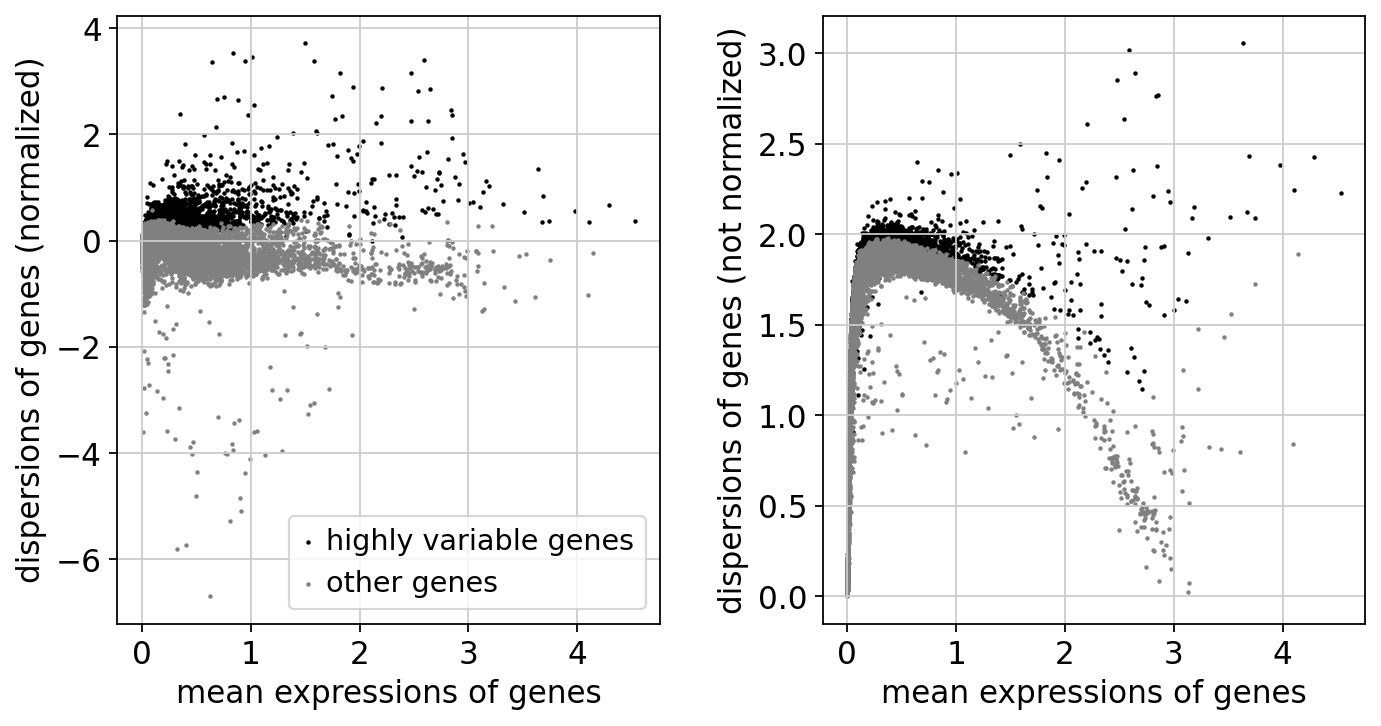

In [15]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key="biosample_id"
)

sc.pl.highly_variable_genes(adata)

In [17]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg)
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg)

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:22)
computing neighbors
    using 'X_pca' with n_pcs = 30


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:33)
computing UMAP
    finished (0:00:56)


In [18]:
n_sub = 10000

if adata_hvg.n_obs > n_sub:
    idx = np.random.choice(adata_hvg.n_obs, n_sub, replace=False)
    adata_plot = adata_hvg[idx].copy()
else:
    adata_plot = adata_hvg.copy()

adata_plot

AnnData object with n_obs × n_vars = 10000 × 3000
    obs: 'biosample_id', 'donor_id', 'SpecimenType', 'TissueSource', 'ProcessingMethod', 'PatientTypeID', 'sex', 'Site', 'Grade', 'TumorStage', 'LymphNodeStatus', 'MMRStatusTumor', 'MMRMLH1Tumor', 'qc_geneCount', 'qc_logMappedReads', 'qc_meanReadsPerUmi', 'qc_totalReads', 'qc_logUmiCount', 'qc_bcSwapFraction', 'qc_geneSatFraction', 'qc_seqDupEst', 'qc_umiSatFraction', 'qc_emptyDropPval', 'qc_mitoFraction', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'ClusterFull', 'ClusterMidway', 'ClusterTop'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

the obs value 'biosample_id' has more than 103 categories. Uniform 'grey' color will be used for all categories.


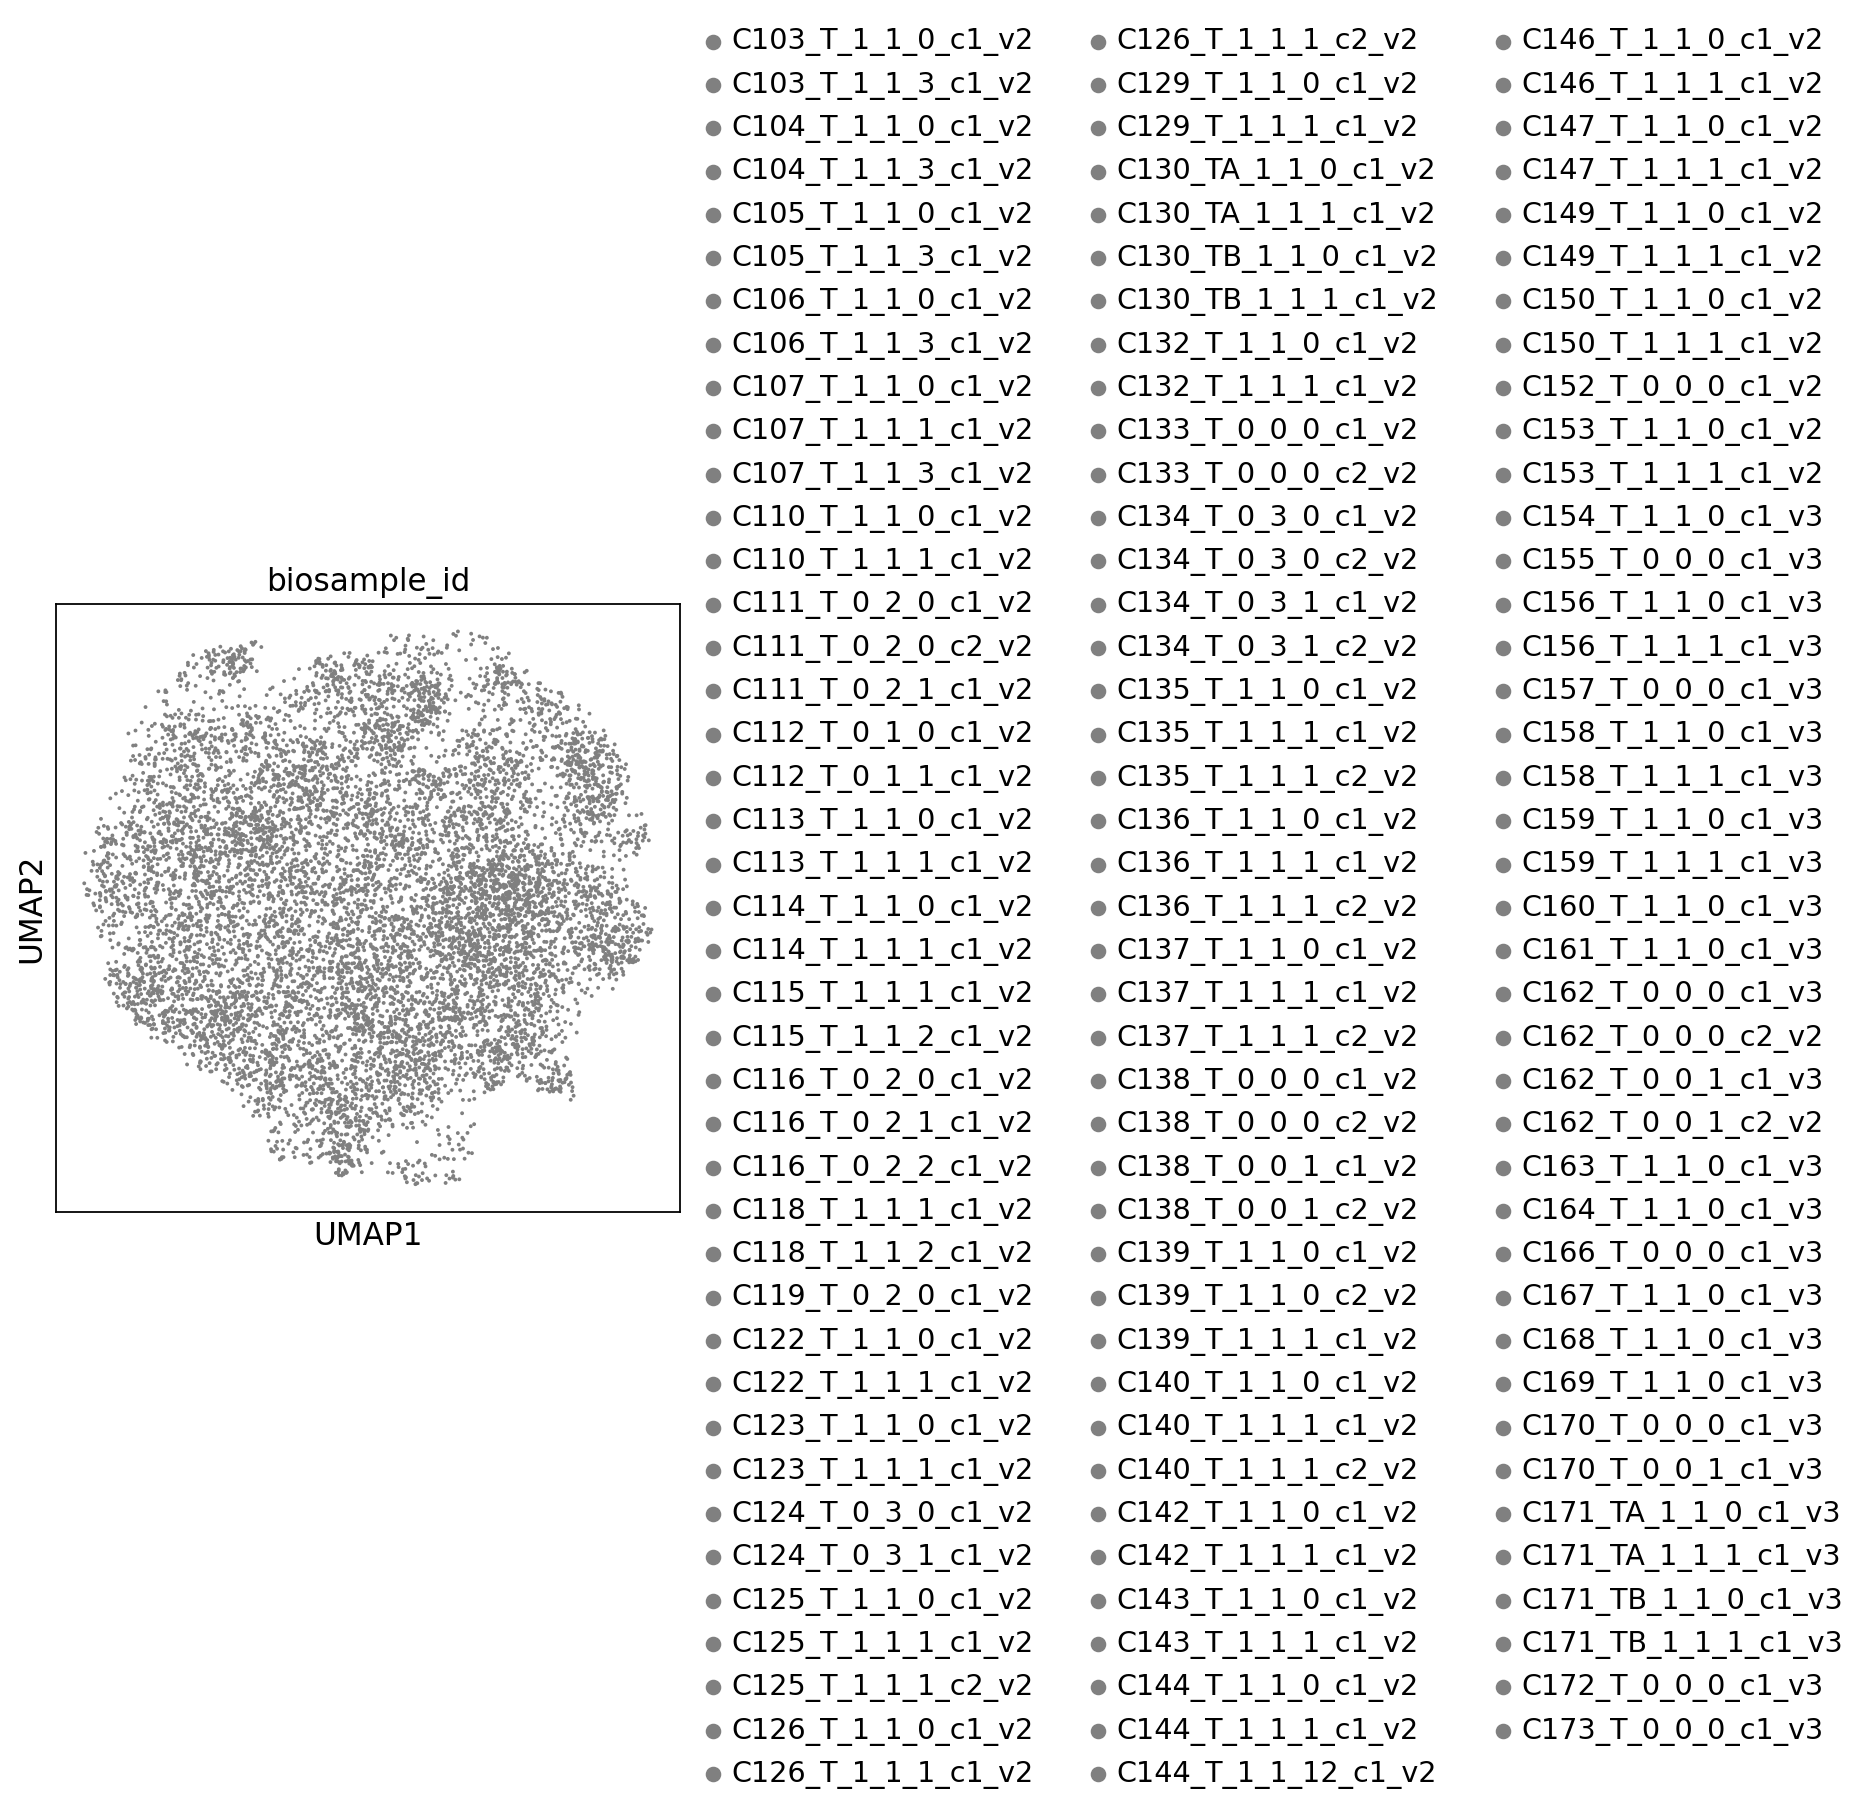

In [19]:
sc.pl.umap(adata_plot, color="biosample_id")

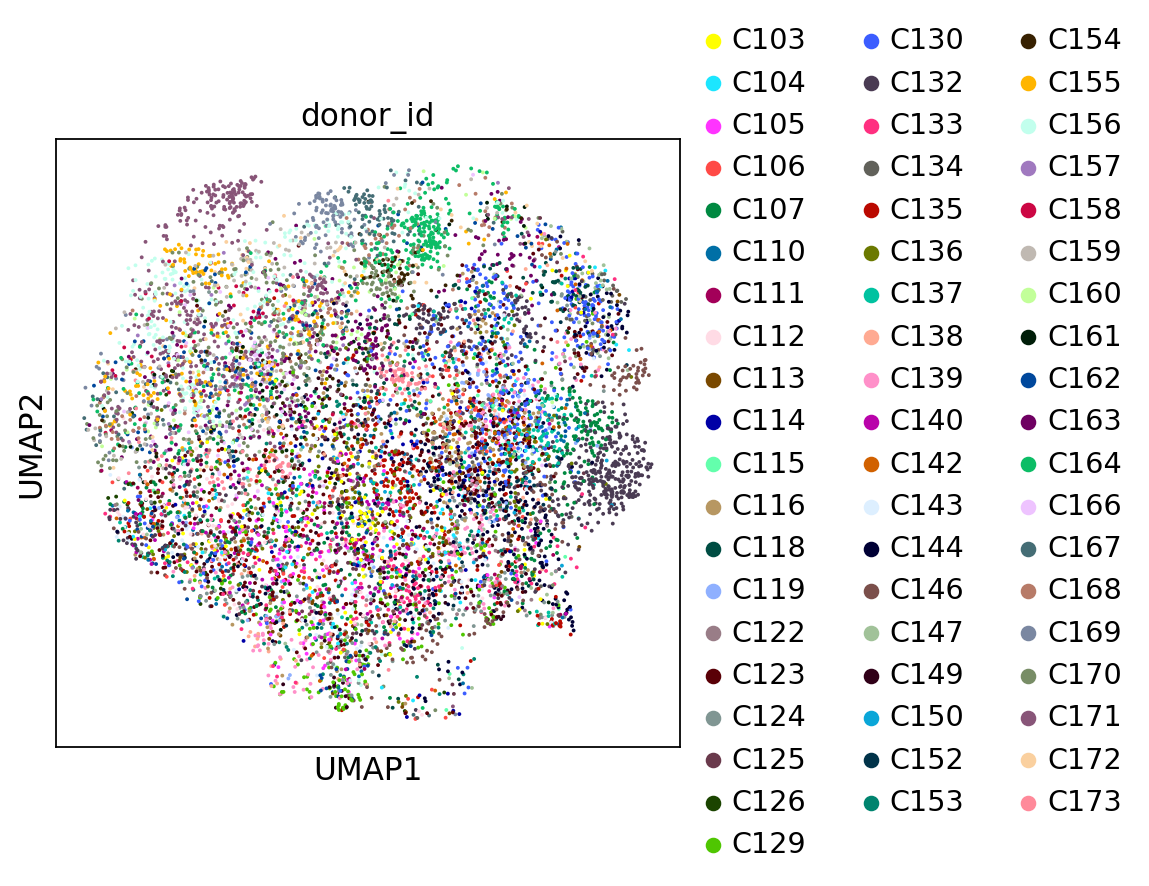

In [20]:
sc.pl.umap(adata_plot, color="donor_id")

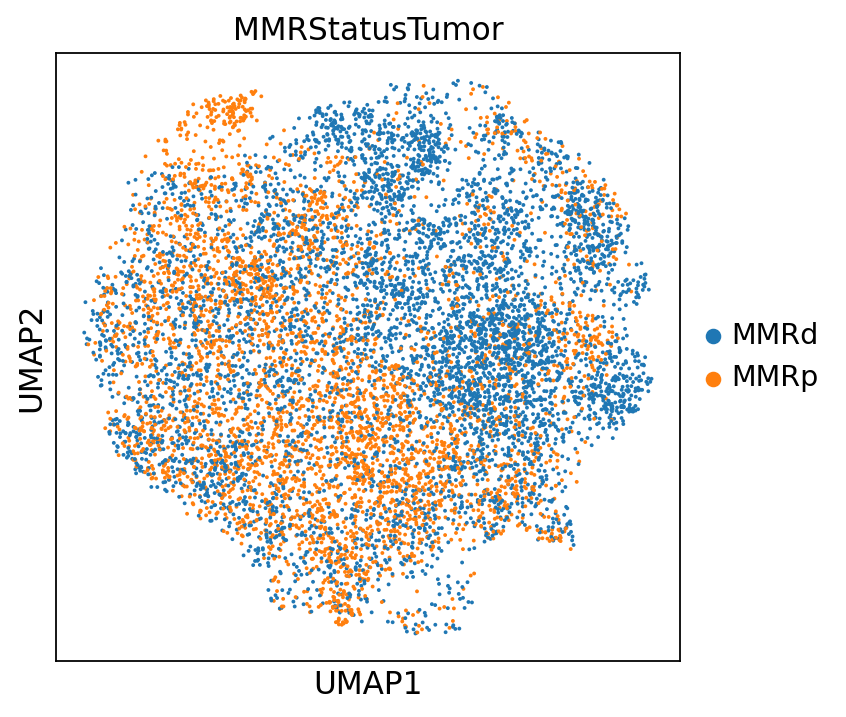

In [21]:
sc.pl.umap(adata_plot, color="MMRStatusTumor")